In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

LOGS = {
    'DAPO':     '../results/grpo/dapo_g16/train_log_dapo.csv',
    'Dr. GRPO': '../results/grpo/dr_grpo_g16/train_log_dr_grpo.csv',
}
COLORS = {'DAPO': '#e07b39', 'Dr. GRPO': '#3a86ff'}
OUT_PATH = '../figures/dapo_training_curves.png'
SMOOTH = 50

In [2]:
dfs = {}
for name, path in LOGS.items():
    df = pd.read_csv(path)
    df = df.apply(pd.to_numeric, errors='coerce')
    dfs[name] = df
    print(f'{name}: {len(df)} steps')

DAPO: 4601 steps
Dr. GRPO: 4601 steps


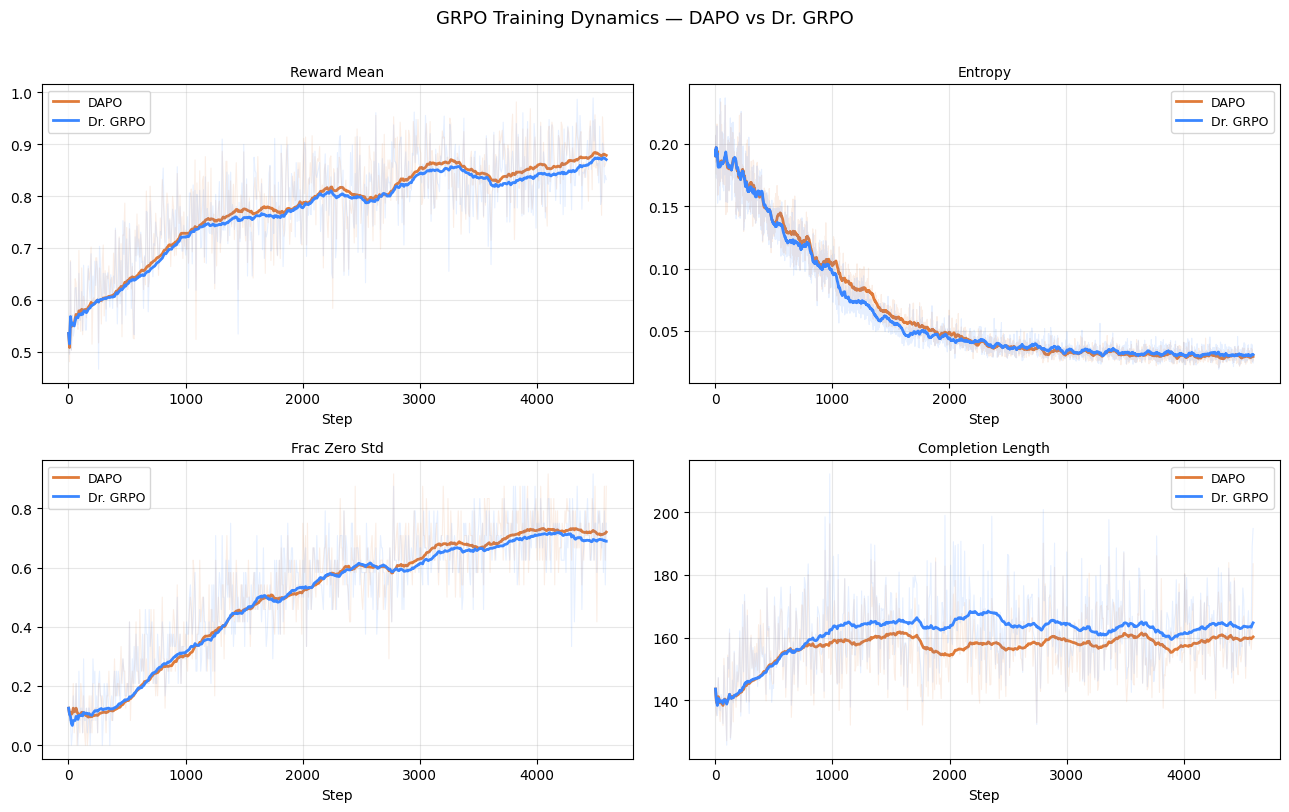

Saved to ../figures/dapo_training_curves.png


In [4]:
METRICS = [
    ('reward_mean',   'Reward Mean',        'Higher is better'),
    ('entropy',       'Entropy',            'Policy diversity'),
    ('frac_zero_std', 'Frac Zero Std',      'Fraction of batches with identical rewards'),
    ('completion_len','Completion Length',  'Mean response length (tokens)'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
fig.suptitle('GRPO Training Dynamics — DAPO vs Dr. GRPO', fontsize=13, y=1.01)

for ax, (col, title, note) in zip(axes, METRICS):
    for name, df in dfs.items():
        s = df[col].dropna()
        if s.empty:
            continue
        steps = df.loc[s.index, 'step']
        smoothed = s.rolling(SMOOTH, min_periods=1).mean()

        ax.plot(steps, s, alpha=0.12, color=COLORS[name], linewidth=0.8)
        ax.plot(steps, smoothed, label=name, color=COLORS[name], linewidth=2)

    ax.set_title(f'{title}', fontsize=10)
    ax.set_xlabel('Step')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {OUT_PATH}')
